# 12장 - LangGraph 기본

원본 파일: `chap12/langgraph_basic.py`

In [9]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

load_dotenv()

model = ChatOpenAI(
    model="openai/gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv('OPENAI_API_KEY'),
)

In [10]:
class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
        'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

In [11]:
graph_builder = StateGraph(State)

In [12]:
def generate(state: State):
    """주어진 상태를 기반으로 챗봇의 응답 메시지를 생성"""
    return {"messages": [model.invoke(state["messages"])]}

In [13]:
graph_builder.add_node("generate", generate)
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

## 그래프 구조 시각화

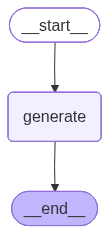

In [14]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # 실패 시 통과 (mermaid 렌더링 서버 접속 불가 등)
    pass

## 실행 / 테스트

In [15]:
response = graph.invoke({"messages": ["안녕하세요! 저는 최세민 입니다"]})
print(type(response))
print(response)

<class 'dict'>
{'messages': [HumanMessage(content='안녕하세요! 저는 최세민 입니다', additional_kwargs={}, response_metadata={}, id='2e53d4c8-3c60-4f9f-8a52-0ceb9c1b0779'), AIMessage(content='안녕하세요, 최세민님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 15, 'total_tokens': 36, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 1.485e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 1.485e-05, 'upstream_inference_prompt_cost': 2.25e-06, 'upstream_inference_completions_cost': 1.26e-05}}, 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_5eaa148bd2', 'id': 'gen-1783065681-4WmNB0JJMI8yVXfGEz5d', 'service_tier': None, 'finish_reason': 'stop', 'logprobs': None},

In [16]:
response["messages"].append("제 이름을 아시나요?")
print("\n===== 메시지 추가 후 응답 =====")
print(graph.invoke(response))


===== 메시지 추가 후 응답 =====
{'messages': [HumanMessage(content='안녕하세요! 저는 최세민 입니다', additional_kwargs={}, response_metadata={}, id='2e53d4c8-3c60-4f9f-8a52-0ceb9c1b0779'), AIMessage(content='안녕하세요, 최세민님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 15, 'total_tokens': 36, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 1.485e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 1.485e-05, 'upstream_inference_prompt_cost': 2.25e-06, 'upstream_inference_completions_cost': 1.26e-05}}, 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_5eaa148bd2', 'id': 'gen-1783065681-4WmNB0JJMI8yVXfGEz5d', 'service_tier': None, 'finish_reason': 'stop', 'logprob

In [17]:
print("\n===== 스트리밍 출력 =====")
inputs = {"messages": [("human", "한국과 일본의 관계에 대해 자세히 알려줘")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")
print()


===== 스트리밍 출력 =====
한국과 일본의 관계는 역사적, 문화적, 정치적, 경제적 측면에서 복잡하고 다층적인 성격을 가지고 있습니다. 아래에서 각 측면을 간략히 살펴보겠습니다.

### 1. 역사적 배경
- **일제강점기 (1910-1945)**: 한국은 1910년부터 1945년까지 일본의 식민지였습니다. 이 시기 동안 한국의 문화, 언어, 전통 등이 억압받았고, 많은 한국인들이 강제 노동과 위안부 문제 등으로 고통받았습니다. 이 역사적 경험은 현재 한국인들에게 강한 감정적 영향을 미치고 있습니다.
- **역사 교과서 문제**: 일본의 역사 교과서에서 일제 강점기의 전쟁 범죄와 관련된 내용을 축소하거나 왜곡하는 경우가 있어, 이는 한국 내에서 많은 논란을 일으킵니다.

### 2. 정치적 관계
- **외교적 긴장**: 역사 문제, 독도(다케시마) 영유권 분쟁, 위안부 문제 등이 양국 간의 긴장을 유발하고 있습니다. 정치적 리더십 변화에 따라 양국 관계는 변동성이 큽니다.
- **한일 정상 회담**: 양국 정상 간의 회담이 있을 때마다 관계 개선의 가능성이 제기되기도 하지만, 역사 문제나 정치적 이슈가 걸림돌이 됩니다.

### 3. 경제적 관계
- **무역**: 한국과 일본은 서로의 주요 무역 파트너입니다. 특히 전자, 자동차, 화학 산업에서 주요한 교역을 하고 있습니다.
- **경제 협력**: 두 나라는 또한 기술 협력과 투자 측면에서도 중요한 관계를 유지하고 있습니다. 그러나 정치적 갈등이 경제적 관계에 부정적인 영향을 미치는 경우도 많습니다.

### 4. 문화적 교류
- **K-POP과 일본**: 최근 몇 년 간 K-POP, 드라마 등 한국 문화가 일본에서 큰 인기를 얻고 있으며, 이는 양국 간의 문화 교류를 촉진하는 긍정적인 요소로 작용하고 있습니다.
- **일본 문화의 영향**: 반대로 일본의 애니메이션, 만화, 영화 등도 한국에서 많은 사랑을 받고 있습니다. 이러한 문화적 접근은 양국 국민 간의 이해를 높이는 데 기여하고 있습니다.

#